In [1]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt

from PatchDataset import load_dataset, load_augmented_dataset

import pipeline
from pipeline import fit_binary_classifier, predict_probs, set_seed


In [3]:
PATCH_SIZE = 224
BATCH_SIZE = 32
SEED = 42

PATCHES_ROOT = "patches_dataset/patches_v3_seed42_pad1.6_iouth0.09"
traincsv_path = os.path.join(PATCHES_ROOT, "metadata.csv")
test_csv = "patches_dataset/test_patches_v3/test_metadata.csv"

set_seed(SEED)


In [4]:
AUG_ROOT = "patches_dataset/patches_v3_train_aug"
PATH_AUG_METADATA = os.path.join(AUG_ROOT, "metadata.csv")

In [5]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("device:", device)

device: mps


In [6]:
# loading the dataset
traindf = pd.read_csv(traincsv_path)
traindf["patch_id"] = traindf["patch_id"].astype(int)
traindf["label"] = traindf["label"].astype(int)
traindf["type"] = traindf["type"].astype(str)

testdf = pd.read_csv(test_csv)
testdf["patch_id"] = testdf["patch_id"].astype(int)
testdf["label"] = testdf["label"].astype(int)
testdf["type"] = testdf["type"].astype(str)

train_dataset,val_dataset,train_loader,val_loader,test_dataset,test_loader = load_dataset(traindf,testdf,PATCHES_ROOT,BATCH_SIZE)

for xb,yb in train_loader:
    print(xb.shape,yb.shape,min(yb),max(yb))
    break

train/val: 15858 3965
torch.Size([32, 3, 224, 224]) torch.Size([32]) tensor(0) tensor(1)


In [7]:
print("train:", traindf.shape, "test:", testdf.shape)
print(traindf["label"].value_counts(dropna=False).sort_index())
print(testdf["label"].value_counts(dropna=False).sort_index())

train: (19823, 6) test: (3965, 6)
label
0     6246
1    13577
Name: count, dtype: int64
label
0    1249
1    2716
Name: count, dtype: int64


In [8]:
class SimpleCNN3(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1) # 3 bc RGB 
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1) # archi 16/32/64
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.head = nn.Linear(64, 2) # couche classif finale FC, classif binaire donc 2 scores pour pipeline.py

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x) # pour non linéarité sans vanishing gradient
        x = self.pool(x)

        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool(x)

        x = self.conv3(x)
        x = F.relu(x)

        x = x.mean(dim=[2, 3])  # Global Average Pooling
        logits = self.head(x)
        return logits


In [9]:
#-----------------------------------------------------------------------------------

In [10]:
def build_model():
    model = SimpleCNN3().to(device)
    return model


def build_loss_and_optimizer(model, train_df, lr=1e-3):
    class_counts = train_df["label"].value_counts().sort_index()
    neg = int(class_counts.get(0, 0))
    pos = int(class_counts.get(1, 0))

    # pondérer la classe positive pour garder rééquilibrage
    # poids classe 0 = 1.0 ; poids classe 1 = neg / pos
    class_weights = torch.tensor([1.0, neg / max(pos, 1)], dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights) # classif binaire avec 2 logits (to use pipeline.ipynb)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    return criterion, optimizer


In [11]:
# helper pour lancer une expérience pipeline.py sur un jeu de loaders
def run_experiment(train_dataset, val_dataset, train_loader, val_loader, test_dataset, test_loader, run_dir, train_df, experiment_name):
    model = build_model()
    criterion, optimizer = build_loss_and_optimizer(model, train_df, lr=1e-3)

    config = {
        "model": "SimpleCNN3",
        "batch_size": BATCH_SIZE,
        "epochs": 10,
        "learning_rate": 1e-3,
        "loss": "CrossEntropyLoss",
        "patch_size": PATCH_SIZE,
        "seed": SEED,
        "experiment": experiment_name,
    }

    pipeline.SAVING_FILE_NAME = os.path.join(run_dir, "best_model")

    run_info, best_model = fit_binary_classifier(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        run_dir=run_dir,
        config=config,
        patience=5,
        monitor="f1",
    )

    y_true, scores = predict_probs(best_model, test_loader, device)
    preds05 = (scores >= 0.5).astype(int)
    preds07 = (scores >= 0.7).astype(int)

    print(experiment_name)
    print("test @0.5")
    print(confusion_matrix(y_true, preds05))
    print(classification_report(y_true, preds05, target_names=["Negative", "Positive"]))

    return {
        "run_info": run_info,
        "best_model": best_model,
        "y_true": y_true,
        "scores": scores,
        "preds05": preds05,
        "preds07": preds07,
    }


In [12]:
# loading the dataset
train_dataset, val_dataset, train_loader, val_loader, test_dataset, test_loader = load_dataset(
    traindf, testdf, PATCHES_ROOT, BATCH_SIZE
)

for xb, yb in train_loader:
    print(xb.shape, yb.shape, min(yb), max(yb))
    break


train/val: 15858 3965
torch.Size([32, 3, 224, 224]) torch.Size([32]) tensor(0) tensor(1)


In [13]:
normal_results = run_experiment(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    train_loader=train_loader,
    val_loader=val_loader,
    test_dataset=test_dataset,
    test_loader=test_loader,
    run_dir="runs/cnn_boxes_v3_normal",
    train_df=traindf,
    experiment_name="CNN on v3 normal",
)


Model improved
Epoch 001 | train loss 0.5487 f1 0.7980 acc 0.7362 | val loss 0.5071 f1 0.7861 acc 0.7395 | 
patience 1/5
Epoch 002 | train loss 0.5093 f1 0.8152 acc 0.7610 | val loss 0.5022 f1 0.7606 acc 0.7158 | 
Model improved
Epoch 003 | train loss 0.4941 f1 0.8193 acc 0.7654 | val loss 0.4684 f1 0.8440 acc 0.7929 | 
Model improved
Epoch 004 | train loss 0.4816 f1 0.8261 acc 0.7729 | val loss 0.4815 f1 0.8710 acc 0.8164 | 
patience 1/5
Epoch 005 | train loss 0.4666 f1 0.8326 acc 0.7796 | val loss 0.4352 f1 0.8471 acc 0.7965 | 
Model improved
Epoch 006 | train loss 0.4500 f1 0.8422 acc 0.7908 | val loss 0.4374 f1 0.8749 acc 0.8252 | 
patience 1/5
Epoch 007 | train loss 0.4505 f1 0.8441 acc 0.7927 | val loss 0.4281 f1 0.8247 acc 0.7760 | 
Model improved
Epoch 008 | train loss 0.4405 f1 0.8498 acc 0.7993 | val loss 0.4007 f1 0.8780 acc 0.8335 | 
patience 1/5
Epoch 009 | train loss 0.4312 f1 0.8552 acc 0.8060 | val loss 0.4001 f1 0.8584 acc 0.8126 | 
patience 2/5
Epoch 010 | train loss 

In [14]:
# loading the augmented dataset
aug_train_dataset, aug_val_dataset, aug_train_loader, aug_val_loader, aug_test_dataset, aug_test_loader = load_augmented_dataset(
    PATCHES_ROOT,
    AUG_ROOT,
    PATH_AUG_METADATA,
    test_csv,
    BATCH_SIZE
)
for xb, yb in aug_train_loader:
    print(xb.shape, yb.shape, min(yb), max(yb))
    break


train_aug/test: 25372 3965
torch.Size([32, 3, 224, 224]) torch.Size([32]) tensor(0) tensor(1)


In [15]:
run_dir = "runs/cnn_boxes_v3_augmented"

model = SimpleCNN3().to(device)

train_labels = [int(aug_train_dataset[i][1]) for i in range(len(aug_train_dataset))]
pos = sum(train_labels)
neg = len(train_labels) - pos

class_weights = torch.tensor(
    [1.0, neg / max(pos, 1)],
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = None

config = {
    "model": "SimpleCNN3",
    "epochs": 10,
    "batch_size": BATCH_SIZE,
    "lr": 1e-3,
    "loss": "CrossEntropyLoss",
    "dataset": "patches_v3_augmented",
}

pipeline.SAVING_FILE_NAME = os.path.join(run_dir, "best_model")

run_info, best_model = fit_binary_classifier(
    model=model,
    train_loader=aug_train_loader,
    val_loader=aug_val_loader,
    test_loader=aug_test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    run_dir=run_dir,
    config=config,
    scheduler=scheduler,
)

Model improved
Epoch 001 | train loss 0.5476 f1 0.7650 acc 0.7246 | val loss 0.5190 f1 0.8040 acc 0.7604 | 
patience 1/5
Epoch 002 | train loss 0.4996 f1 0.7929 acc 0.7597 | val loss 0.5078 f1 0.7462 acc 0.7264 | 
patience 2/5
Epoch 003 | train loss 0.4772 f1 0.8048 acc 0.7722 | val loss 0.4769 f1 0.8028 acc 0.7706 | 
patience 3/5
Epoch 004 | train loss 0.4611 f1 0.8175 acc 0.7851 | val loss 0.4981 f1 0.8003 acc 0.7672 | 
Model improved
Epoch 005 | train loss 0.4439 f1 0.8220 acc 0.7894 | val loss 0.4537 f1 0.8579 acc 0.8157 | 
patience 1/5
Epoch 006 | train loss 0.4251 f1 0.8358 acc 0.8037 | val loss 0.4544 f1 0.7876 acc 0.7620 | 
patience 2/5
Epoch 007 | train loss 0.4189 f1 0.8368 acc 0.8058 | val loss 0.4311 f1 0.8447 acc 0.8090 | 
patience 3/5
Epoch 008 | train loss 0.4101 f1 0.8445 acc 0.8148 | val loss 0.4214 f1 0.8033 acc 0.7812 | 
patience 4/5
Epoch 009 | train loss 0.3971 f1 0.8509 acc 0.8223 | val loss 0.4058 f1 0.8342 acc 0.8044 | 
patience 5/5
Epoch 010 | train loss 0.3900

In [16]:
# affichage normal dataset

In [17]:
# pr quels résultats afficher
results = normal_results
y_true = results["y_true"]
scores = results["scores"]

# y score probas so we make the preds by thresholding at 0.5
preds = (scores >= 0.5).astype(int)

y_true, scores[:10], preds[:10]


(array([1, 1, 1, ..., 0, 1, 1], shape=(3965,)),
 array([0.82105386, 0.9261478 , 0.79819965, 0.2551294 , 0.30173564,
        0.8394127 , 0.45771176, 0.91476136, 0.58636516, 0.6858159 ],
       dtype=float32),
 array([1, 1, 1, 0, 0, 1, 0, 1, 1, 1]))

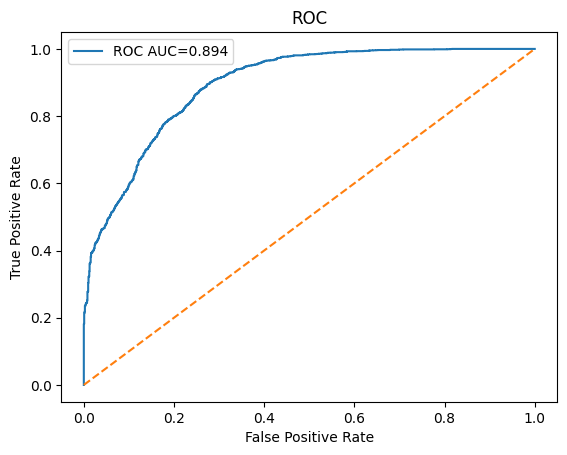

In [18]:
fpr, tpr, _ = roc_curve(y_true, scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC={roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC")
plt.legend()
plt.show()


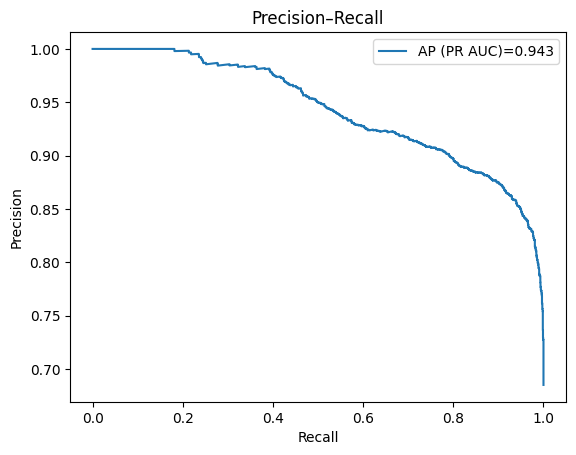

In [19]:
prec, rec, _ = precision_recall_curve(y_true, scores)
ap = average_precision_score(y_true, scores)

plt.figure()
plt.plot(rec, prec, label=f"AP (PR AUC)={ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall")
plt.legend()
plt.show()


In [20]:
print(confusion_matrix(y_true, preds))

# { TN FP 
# FN TP }


[[ 929  320]
 [ 340 2376]]


In [21]:
print("                            Métriques")
print(classification_report(y_true, preds, target_names=["Negative", "Positive"]))


                            Métriques
              precision    recall  f1-score   support

    Negative       0.73      0.74      0.74      1249
    Positive       0.88      0.87      0.88      2716

    accuracy                           0.83      3965
   macro avg       0.81      0.81      0.81      3965
weighted avg       0.83      0.83      0.83      3965



In [22]:
preds = (scores >= 0.7).astype(int) # seuil plus serré...
print(confusion_matrix(y_true, preds))

# { TN FP 
# FN TP }


[[1098  151]
 [ 925 1791]]


In [23]:
print("                            Métriques")
print(classification_report(y_true, preds, target_names=["Negative", "Positive"]))


                            Métriques
              precision    recall  f1-score   support

    Negative       0.54      0.88      0.67      1249
    Positive       0.92      0.66      0.77      2716

    accuracy                           0.73      3965
   macro avg       0.73      0.77      0.72      3965
weighted avg       0.80      0.73      0.74      3965



In [24]:
# affichage data augmentée

In [34]:
best_model.load_state_dict(torch.load("./runs/cnn_boxes_v3_augmented/best_model_SimpleCNN3_None_10.pth", map_location=device))
y_true,y_score = predict_probs(best_model, test_loader, device)

#y score probas so we make the preds by thresholding at 0.5
y_pred = (y_score >= 0.5).astype(int)
y_pred_tighter = (y_score >= 0.7).astype(int)

In [35]:
y_true, y_score, y_pred, y_pred_tighter

(array([1, 1, 1, ..., 0, 1, 1], shape=(3965,)),
 array([0.83217347, 0.9837045 , 0.9112177 , ..., 0.64932   , 0.9439365 ,
        0.9696231 ], shape=(3965,), dtype=float32),
 array([1, 1, 1, ..., 1, 1, 1], shape=(3965,)),
 array([1, 1, 1, ..., 0, 1, 1], shape=(3965,)))

In [36]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_score)  # binary labels must be {0,1}

# AUROC
auc_score = roc_auc_score(y_true, y_score)
print(f"Validation AUROC: {auc_score:.4f}")


Validation AUROC: 0.8935


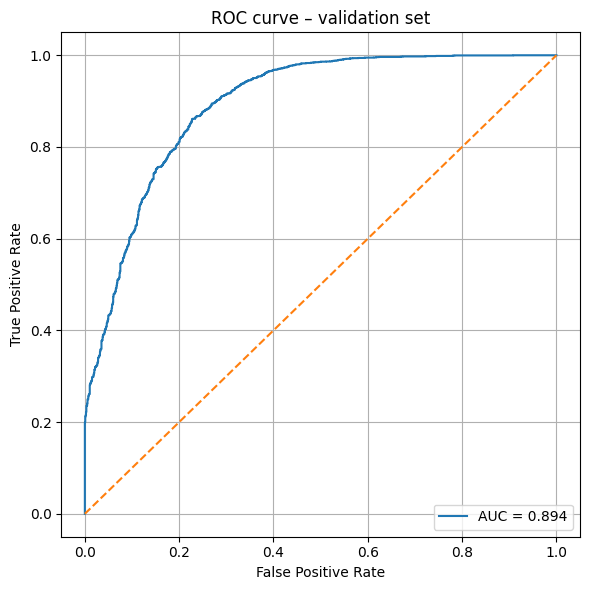

In [37]:
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve – validation set')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


In [29]:
# taille kernel ?
# reduire learning rate 
# automatiser test avec differents seeds
# essayer de ne pas manquer d'arbres, trop de faux negatifs cf precision negative.


In [30]:
print("\n" * 100)